In [953]:
import pandas as pd
import numpy as np
import seaborn.objects as so
from scipy import stats


In [436]:
########## Question 1: Load data ##########
# * ~12% of rows have missing data in (year, school id, or student vol). 
# Mostly in student vol. We exclude these rows from our analysis
# * 0.3% of schools are missing data for certain years. 
# This does not alter the global picture, but can alter it at a country level

In [955]:
en = pd.read_csv("enrollments.csv", dtype={12: str, 13: str})

In [957]:
# en.head()

In [959]:
# en.describe()

In [961]:
# en.shape

In [963]:
en.iau_id1.unique().shape # number of universitiees

(17841,)

In [140]:
##### NULL values in key columns #####
# Removing rows with null years or null estimated students. 
# Drops ~12% of rows. Mostly null student volumes

In [965]:
{
    'student_vol': en.students5_estimated.isna().value_counts(),
    'year': en.year.isna().value_counts(),
    'school_id': en.iau_id1.isna().value_counts()
}

{'student_vol': students5_estimated
 False    142819
 True      18741
 Name: count, dtype: int64,
 'year': year
 False    161525
 True         35
 Name: count, dtype: int64,
 'school_id': iau_id1
 False    161553
 True          7
 Name: count, dtype: int64}

In [989]:
en_nona = en[(
    en.students5_estimated.isna() == False) & (
        en.year.isna() == False) & (en.iau_id1.isna() == False)].copy()

In [991]:
en_nona['iau_id1'].unique().shape

(16955,)

In [993]:
en_nona.shape

(142819, 27)

In [995]:
##### year coverage #####
# Do we have data from the start to the end of the school, 
# do we have data for all years in between? 
# A few 100 schools have missing years. This does not alter the global picture 
# (most student volume is from schools without misssing data). 
# It does impact the country level picture for some countires

In [997]:
yrs = en_nona.groupby(['countrycode', 'iau_id1', 'foundedyr', 'yrclosed'], dropna=False
                     ).agg({'year': ['min', 'max', 'count']})
# yrs

In [999]:
yrs.columns = ['min_yr', 'max_yr', 'count_yr']
yrs.reset_index(inplace=True)
yrs.min_yr.value_counts()

min_yr
1960.0    2297
1950.0    1855
2005.0    1759
2000.0    1693
1995.0    1555
2010.0    1481
1955.0     910
1990.0     902
1975.0     834
1965.0     773
1970.0     769
1985.0     700
2015.0     691
1980.0     632
2020.0     104
Name: count, dtype: int64

In [1001]:
yrs['contain_start'] = np.where(
    yrs.min_yr - yrs.foundedyr <= 5, 'first data within 5yrs of founding', np.where(
        yrs.foundedyr > 1945, 'missing', 'founded 1945-'
    ))
yrs.contain_start.value_counts()

contain_start
first data within 5yrs of founding    12652
founded 1945-                          3587
missing                                 716
Name: count, dtype: int64

In [1003]:
yrs['contain_end'] = np.where(
    yrs.max_yr == 2020, 'thru 2020', np.where(
        yrs.max_yr - yrs.yrclosed <= 5, 'thru closing', 'missing'
    ))
yrs.contain_end.value_counts()

contain_end
thru 2020       16683
missing           215
thru closing       57
Name: count, dtype: int64

In [1005]:
yrs['est_count'] = (yrs.max_yr - yrs.min_yr)/5 + 1
yrs['miss_middle'] = np.where(yrs.est_count != yrs.count_yr, 1, 0)

In [1007]:
yrs['miss_start'] = np.where(yrs['contain_start']== 'missing', 1, 0)
yrs['miss_end'] = np.where(yrs['contain_end']== 'missing', 1, 0)
yrs.groupby(['miss_end', 'miss_start', 'miss_middle']).count()
# most misses are from missing start of range, some from missing end, a few from missing middle

countrycode  iau_id1  foundedyr  yrclosed  \
miss_end miss_start miss_middle                                              
0        0          0                  15913    15953      15953        57   
                    1                     80       81         81         0   
         1          0                    667      704        704         5   
                    1                      2        2          2         0   
1        0          0                    204      205        205         0   
         1          0                     10       10         10         0   

                                 min_yr  max_yr  count_yr  contain_start  \
miss_end miss_start miss_middle                                            
0        0          0             15953   15953     15953          15953   
                    1                81      81        81             81   
         1          0               704     704       704            704   
                    1                 2       2         2              2   
1        0          0               205     205       205            205   
         1          0                10      10        10             10   

                                 contain_end  est_count  
miss_end miss_start miss_middle                          
0        0          0                  15953      15953  
                    1                     81         81  
         1          0                    704        704  
                    1                      2          2  
1        0          0                    205        205  
         1          0                     10         10

In [1009]:
id_with_miss_yrs = yrs[(
    yrs.miss_start == 0) & (yrs.miss_end == 0) & (yrs.miss_middle)].iau_id1.to_list()

In [1011]:
en_nona['miss_yrs'] = np.where(en_nona.iau_id1.isin(id_with_miss_yrs), 'yes', 'no')
vol_miss = en_nona.groupby(['year', 'miss_yrs']).agg({'students5_estimated':'sum'}).reset_index()

In [1013]:
en_nona['miss_yrs'].value_counts() / en_nona.shape[0]

miss_yrs
no     0.99771
yes    0.00229
Name: count, dtype: float64

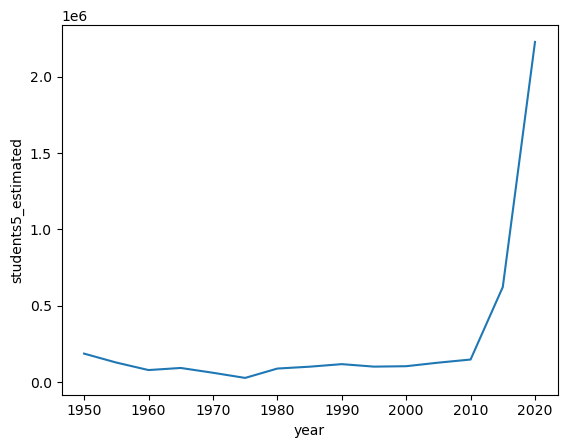

In [1015]:
sns.lineplot(data=vol_miss[vol_miss['miss_yrs'] == 'yes'], x='year', y='students5_estimated')
plt.show()

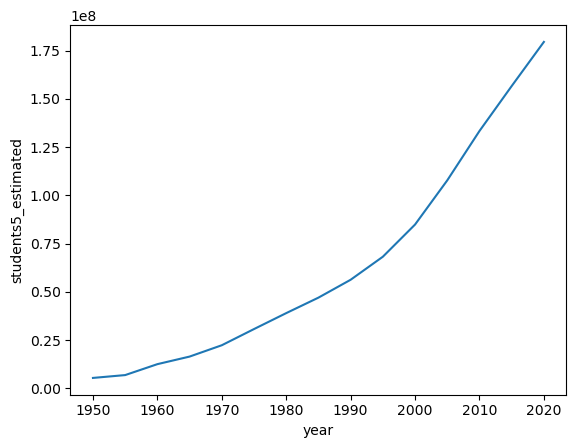

In [1017]:
sns.lineplot(data=vol_miss[vol_miss['miss_yrs'] == 'no'], x='year', y='students5_estimated')
plt.show()

In [1019]:
en_nona['num'] = (en_nona['miss_yrs'] == 'yes') * en_nona['students5_estimated']
y = en_nona.groupby('year').agg({'num': 'sum', 'students5_estimated': 'sum'}).reset_index()
y['pct_from_school_with_miss'] = y.num *1.0 / y.students5_estimated
y
# Schools with missing data do not drastically alter the global picture

,year,num,students5_estimated,pct_from_school_with_miss
0,1950.0,186004.0,5646397.0,0.032942
1,1955.0,127377.0,7059227.0,0.018044
2,1960.0,78139.0,12669536.0,0.006167
3,1965.0,91939.0,16609540.0,0.005535
4,1970.0,60447.0,22448983.0,0.002693
5,1975.0,26603.0,30799578.0,0.000864
6,1980.0,87999.0,39118308.0,0.002250
7,1985.0,100204.0,47147533.0,0.002125
8,1990.0,116934.0,56428945.0,0.002072
9,1995.0,100670.0,68344300.0,0.001473


In [1021]:
en_nona['num'] = (en_nona['miss_yrs'] == 'yes') * en_nona['students5_estimated']
y = en_nona.groupby(['year', 'country']).agg({'num': 'sum', 'students5_estimated': 'sum'}).reset_index()
y['pct_from_school_with_miss'] = y.num *1.0 / y.students5_estimated
y[y['pct_from_school_with_miss'] > 0.05].country.value_counts()

country
syrian arab republic    10
switzerland             10
sri lanka                8
sweden                   6
chile                    6
estonia                  6
uzbekistan               6
egypt                    5
lithuania                5
tajikistan               5
hungary                  4
spain                    3
bulgaria                 3
kazakhstan               3
haiti                    3
greece                   3
philippines              2
netherlands              2
cambodia                 2
brazil                   2
turkey                   1
Name: count, dtype: int64

In [1023]:
########## Question 2: Detecting global events ##########
# Hypothesized detectable events: 
## Wars:
### Gulf: 1990-1991: Iraq, Kuwait, US, UK, France, Saudia Arabia, Egypt*
### Ukraine-Russia: 2015, 2022
## Introduction of birth control: 1960 with restrictions, 1970 more broadly, not until 1999 in Japan:
    # US, France, Japan, Germany, Canada
## Fall of the Berlin wall: 1989: Germany, Russia, Hungary*, Austria

# Findings

## Gulf war
### Kuwait student volume in the early 90s is decreased
### We do not see impact in: Iraq, US, UK, France, Saudia Arabia, or Egypt
## Ukraine-Russia: See a drop in student volumes in the late 2010s in both countries

## Birth control
### The 1960s are too close to the start of the data to detect an angle change
### 1960s also coincide with the baby boomers entering university so it would be hard to 
### associate anything to birth control. The boomer pattern is repeated every generation in the student 
### volume time series (France shows this pattern pretty clearly)

## Fall of the Berlin wall
### Germany and Russia show a small potential nudge up in student volume. 
### Hungary data (needs quality check). Student volume 3x in 20 years
### No impact is detectable in Austria

In [1025]:
country = 'Kuwait'
code = 'KWT'

In [1028]:
cc = 'austria'
en_nona[en_nona['country'].str.contains(str.lower(cc))].countrycode.value_counts()

countrycode
AUT    512
Name: count, dtype: int64

In [1030]:
def make_country_ts(ccode, cname, id_with_miss_yrs):
    en_nona['exclude_ids_with_miss_yrs'] = np.where(
        en_nona.iau_id1.isin(id_with_miss_yrs), 0, en_nona.students5_estimated)
    c_yr = en_nona[en_nona['countrycode'] == ccode].groupby('year').agg(
        {'students5_estimated':'sum', 'exclude_ids_with_miss_yrs': 'sum' })
    return(
        so.Plot(c_yr, x="year")
        .add(so.Line(color="C1"), so.Agg(), y="students5_estimated", label='All available data')
        .add(so.Line(color="C2"), so.Agg(), y="exclude_ids_with_miss_yrs", label='Only universities without missing data')
        .label(x="Year", y="Student volume", title=cname + " student volume over time")
    )

In [1032]:
# Gulf war

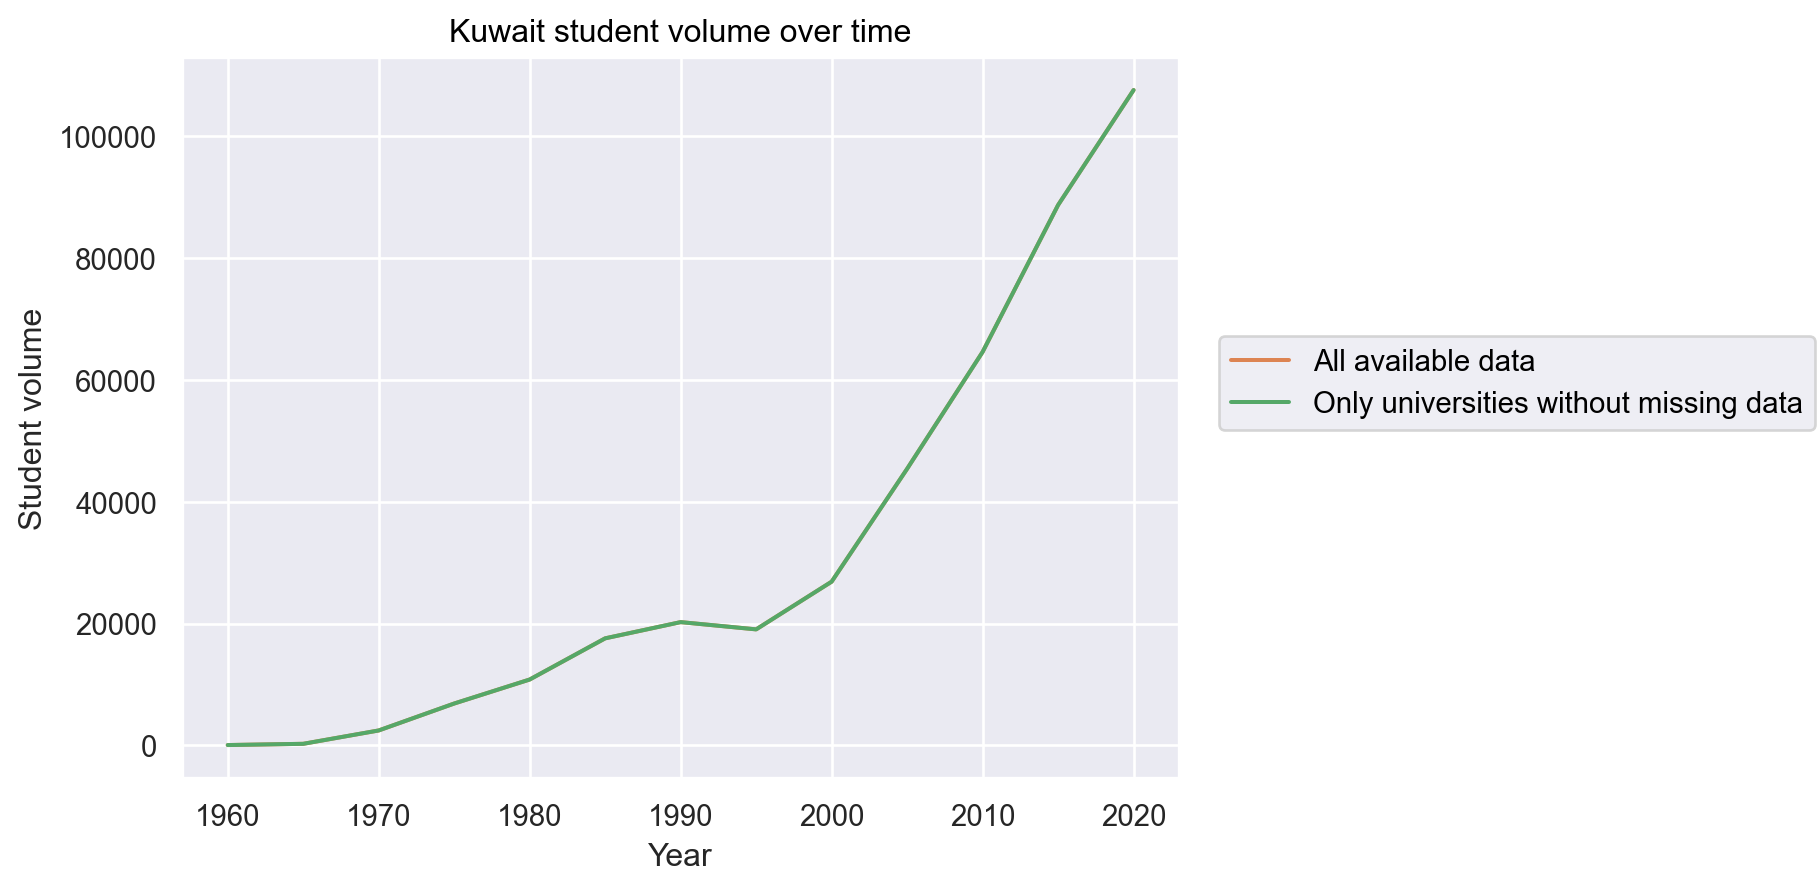

In [1034]:
make_country_ts('KWT', 'Kuwait', id_with_miss_yrs)

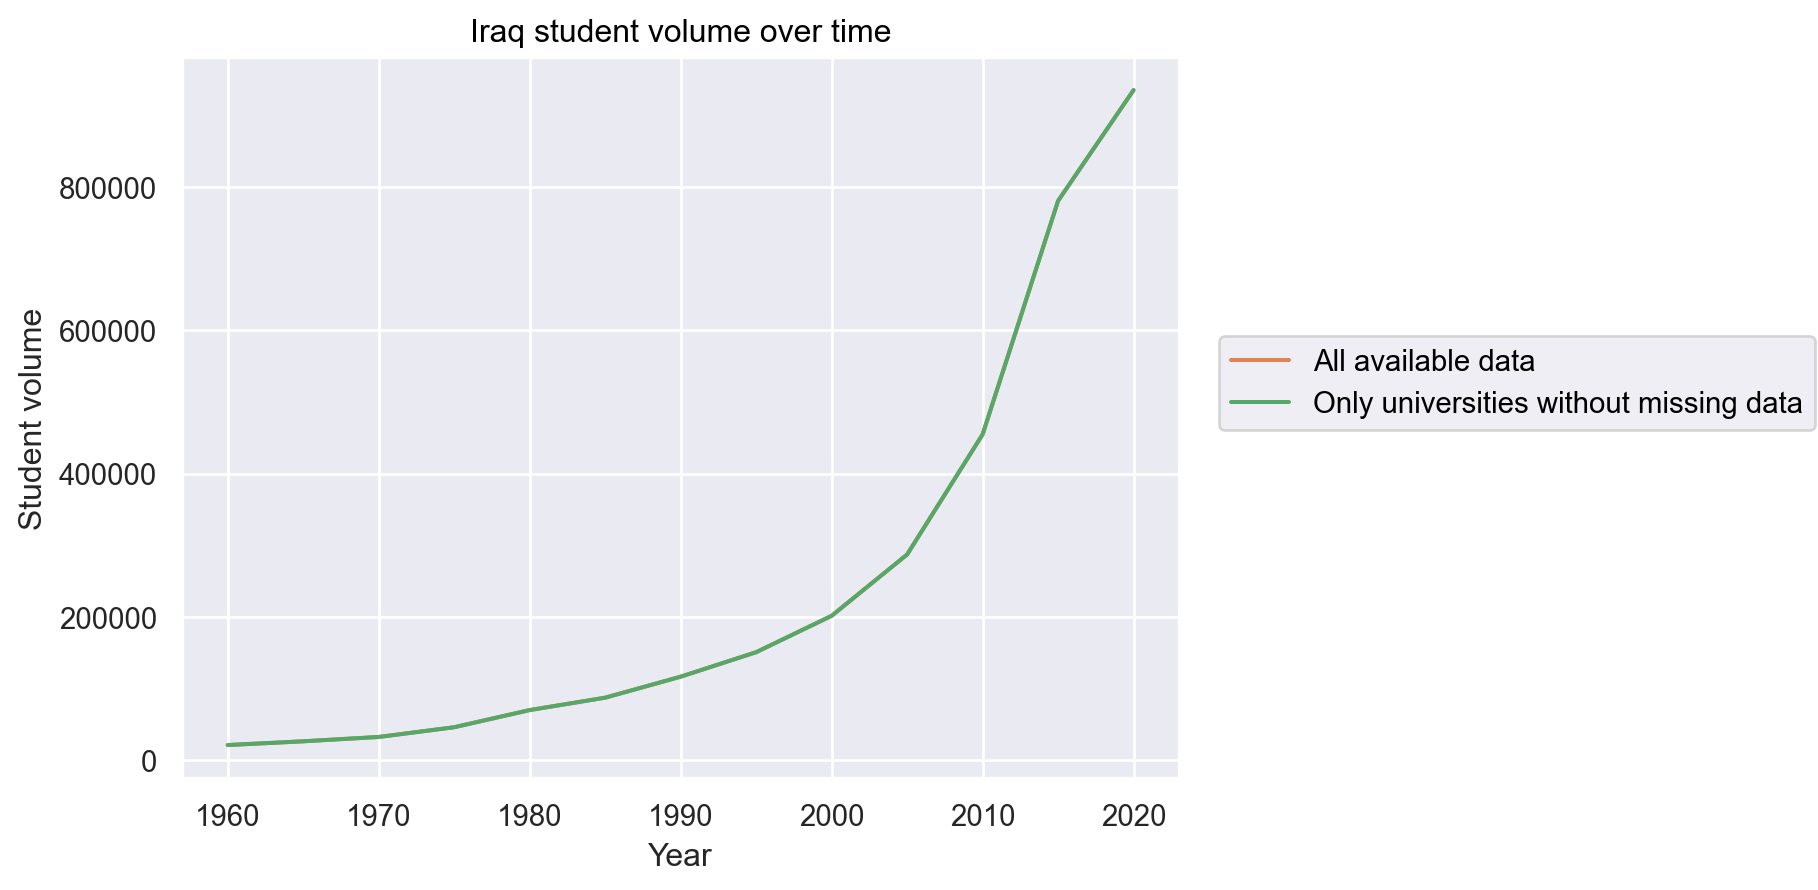

In [1036]:
make_country_ts('IRQ', 'Iraq', id_with_miss_yrs)

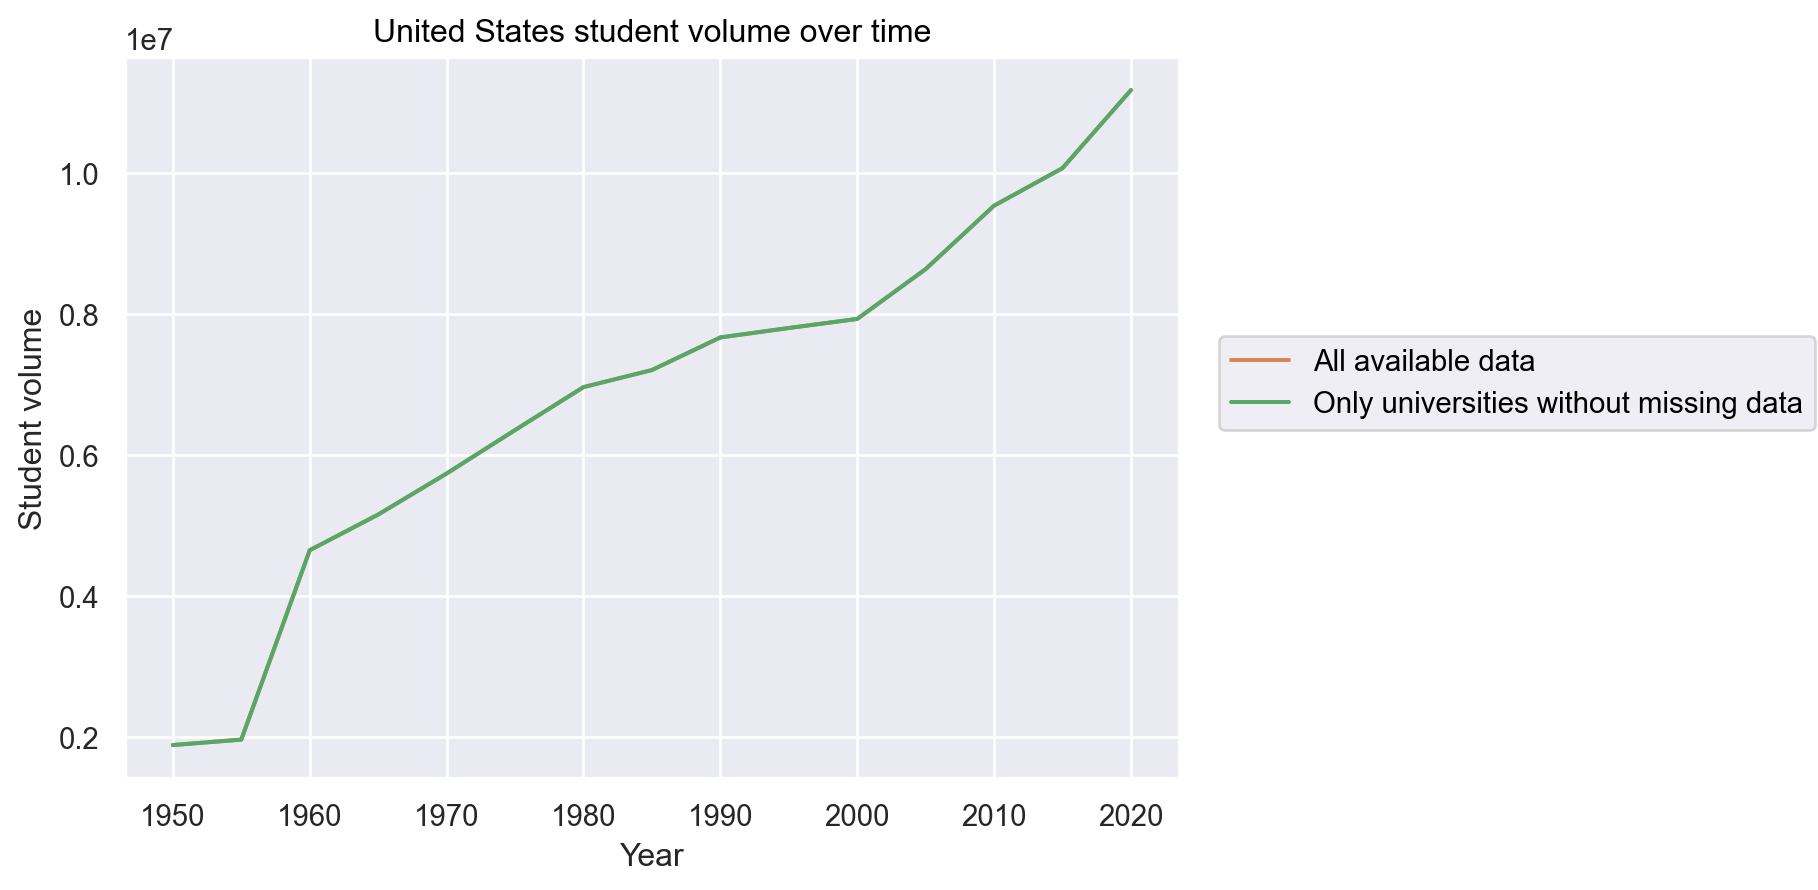

In [1038]:
make_country_ts('USA', 'United States', id_with_miss_yrs)

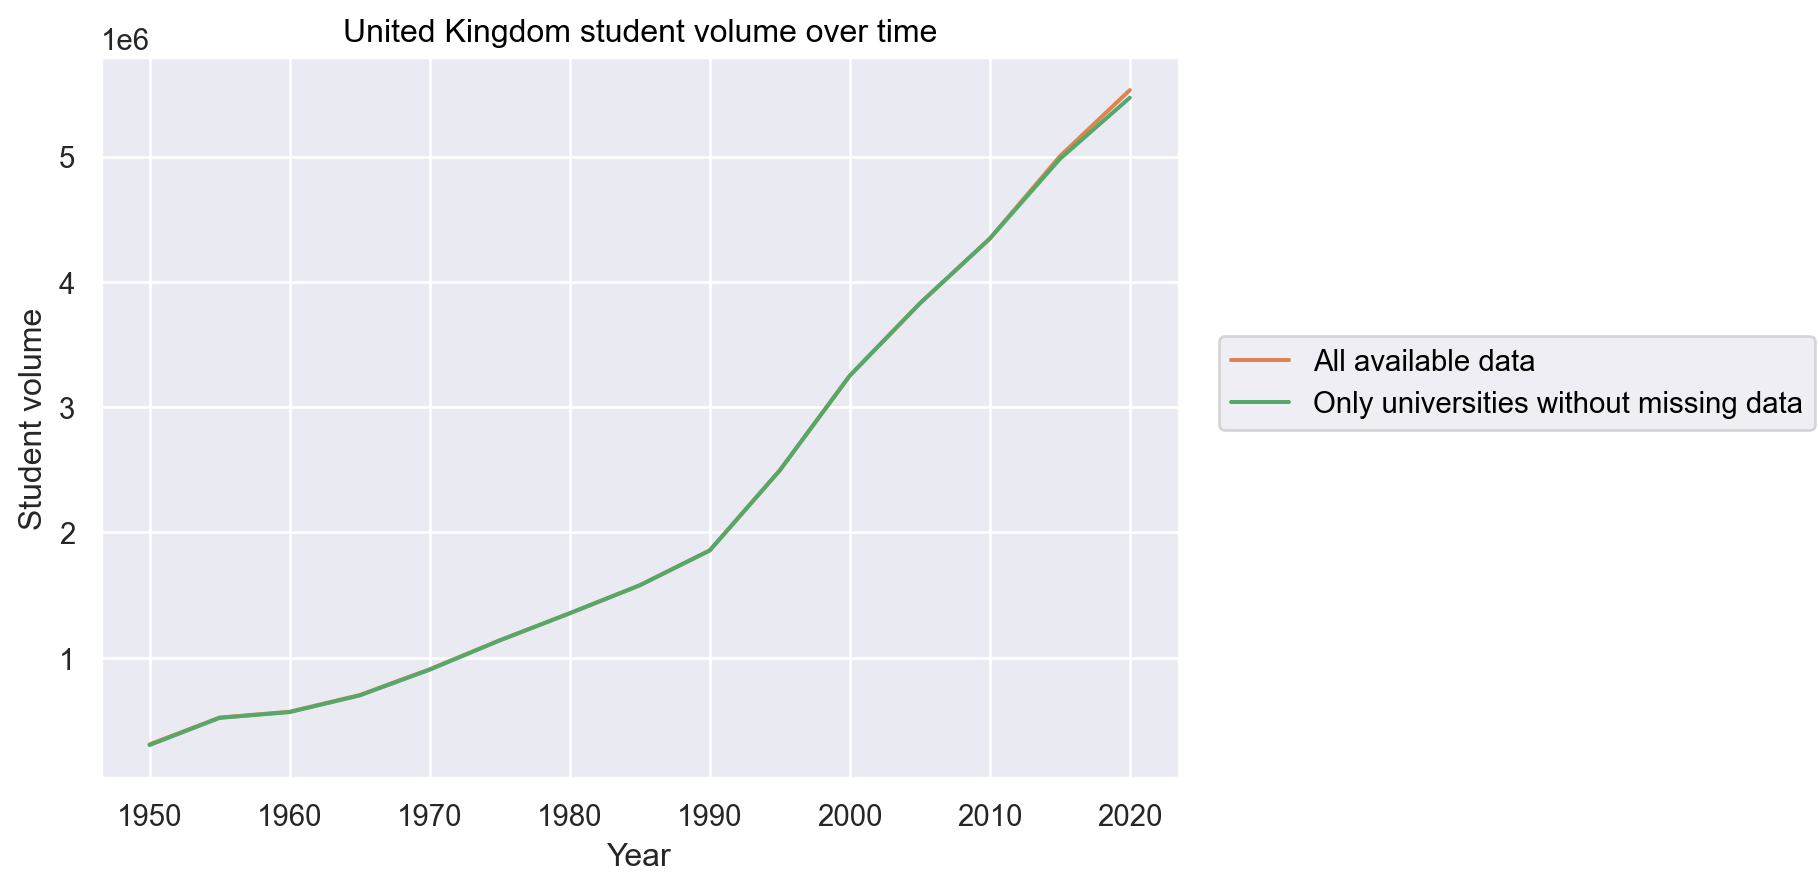

In [1040]:
make_country_ts('GBR', 'United Kingdom', id_with_miss_yrs)

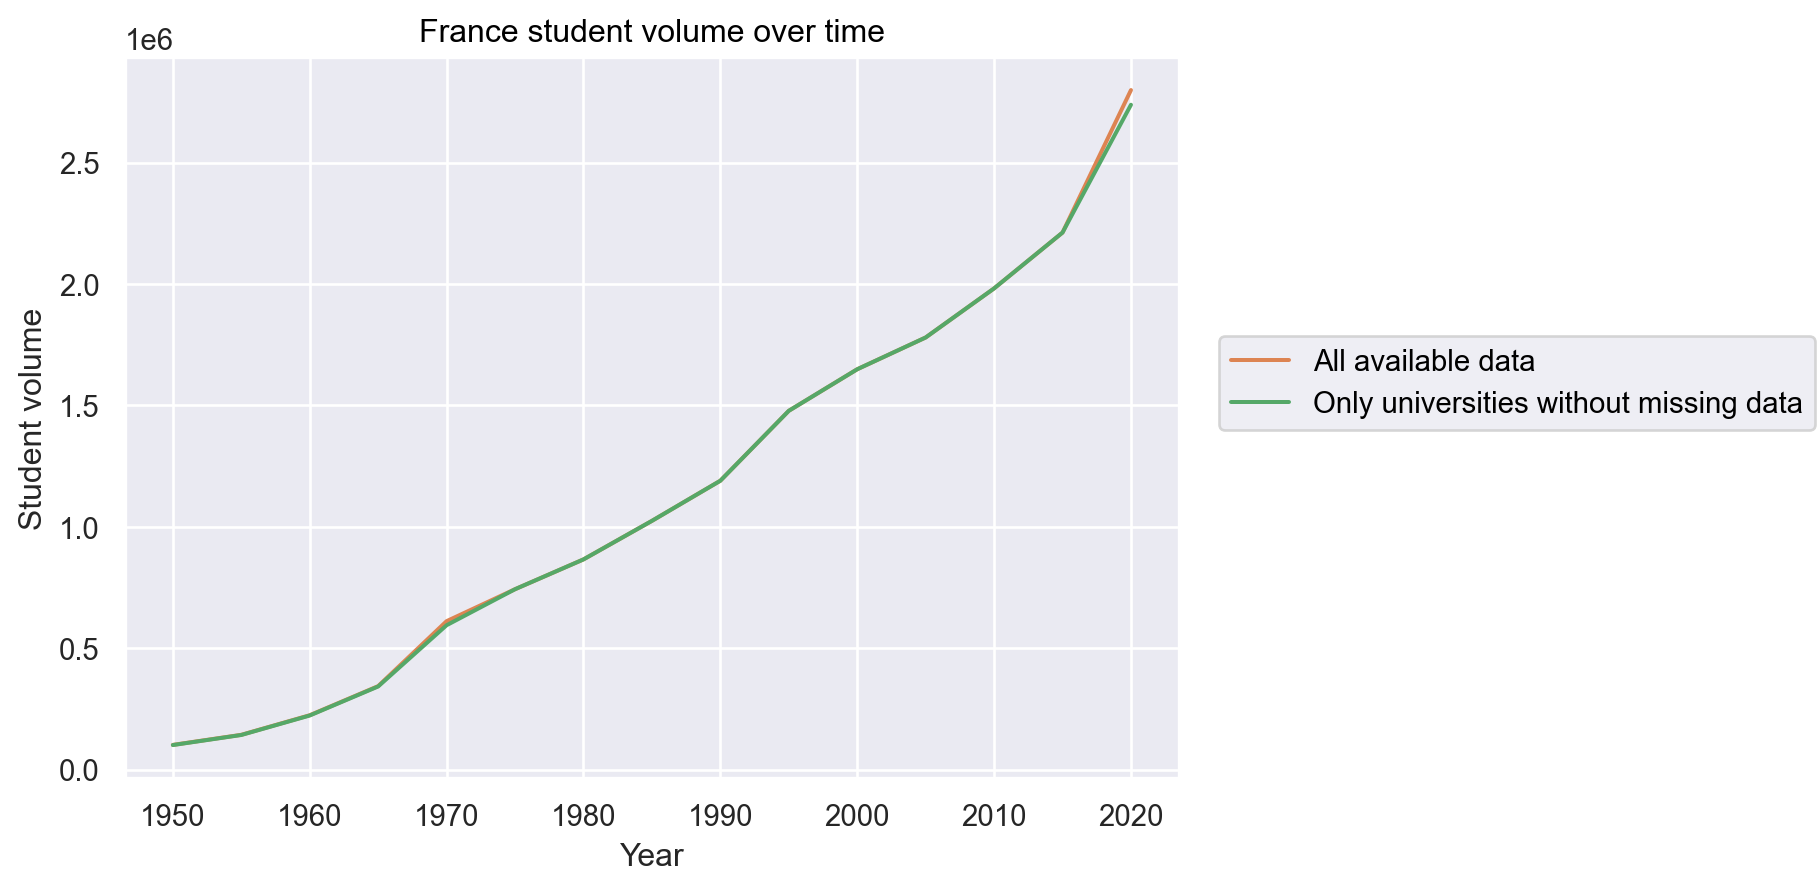

In [1042]:
make_country_ts('FRA', 'France', id_with_miss_yrs)

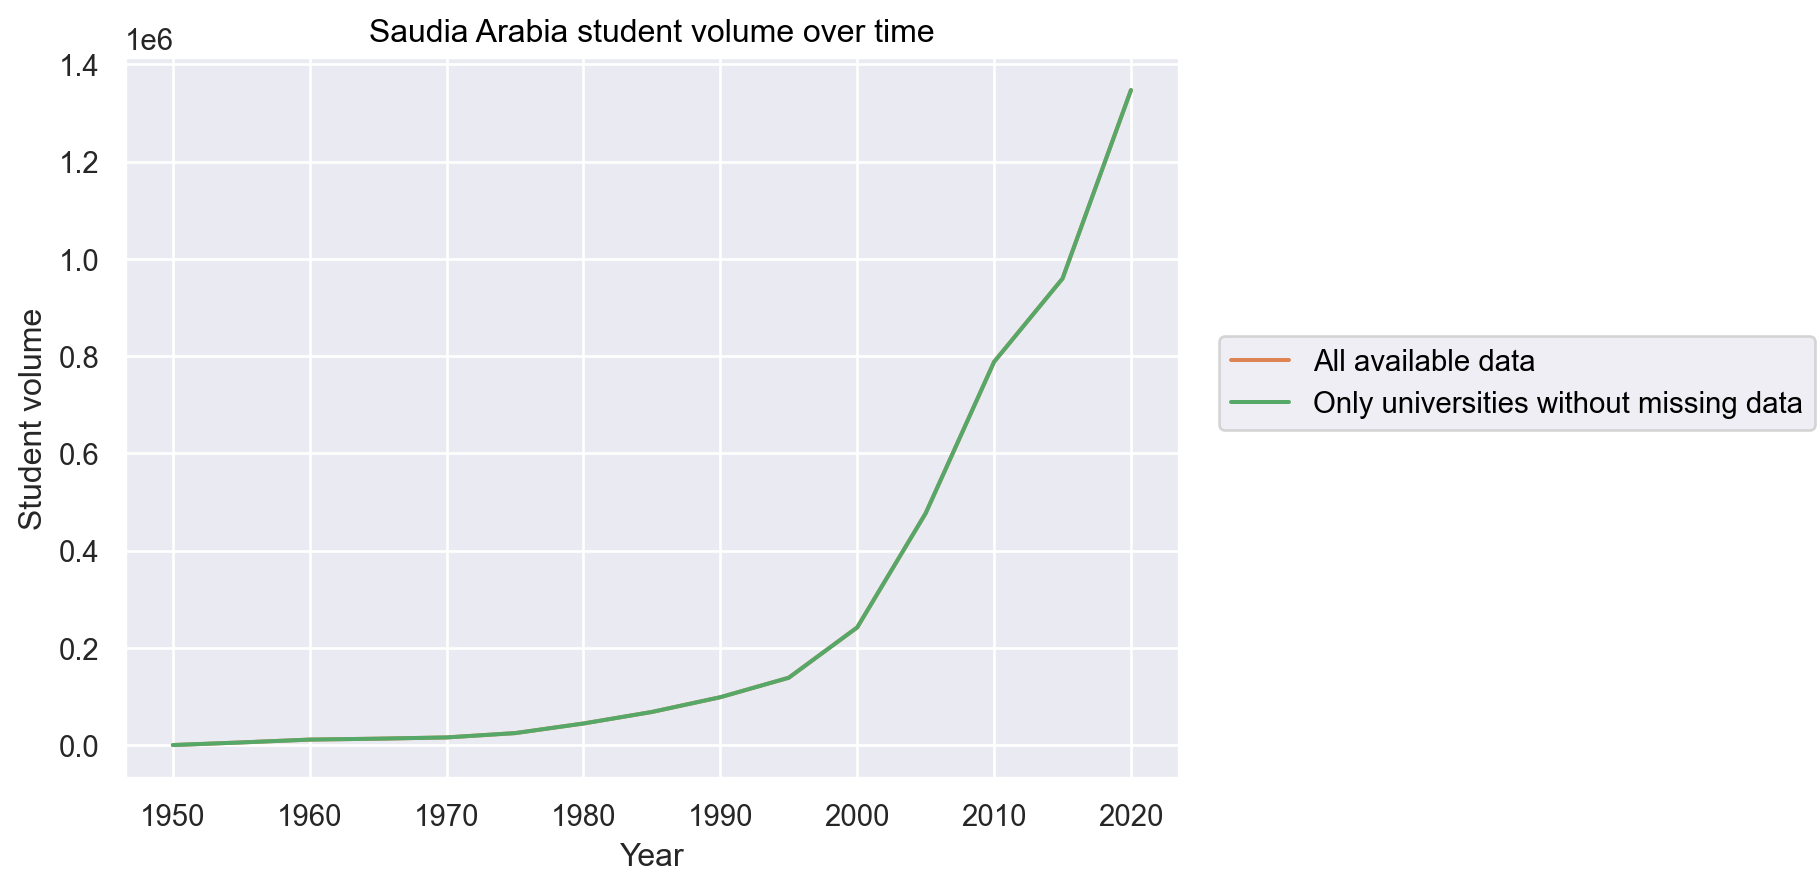

In [1044]:
make_country_ts('SAU', 'Saudia Arabia', id_with_miss_yrs)

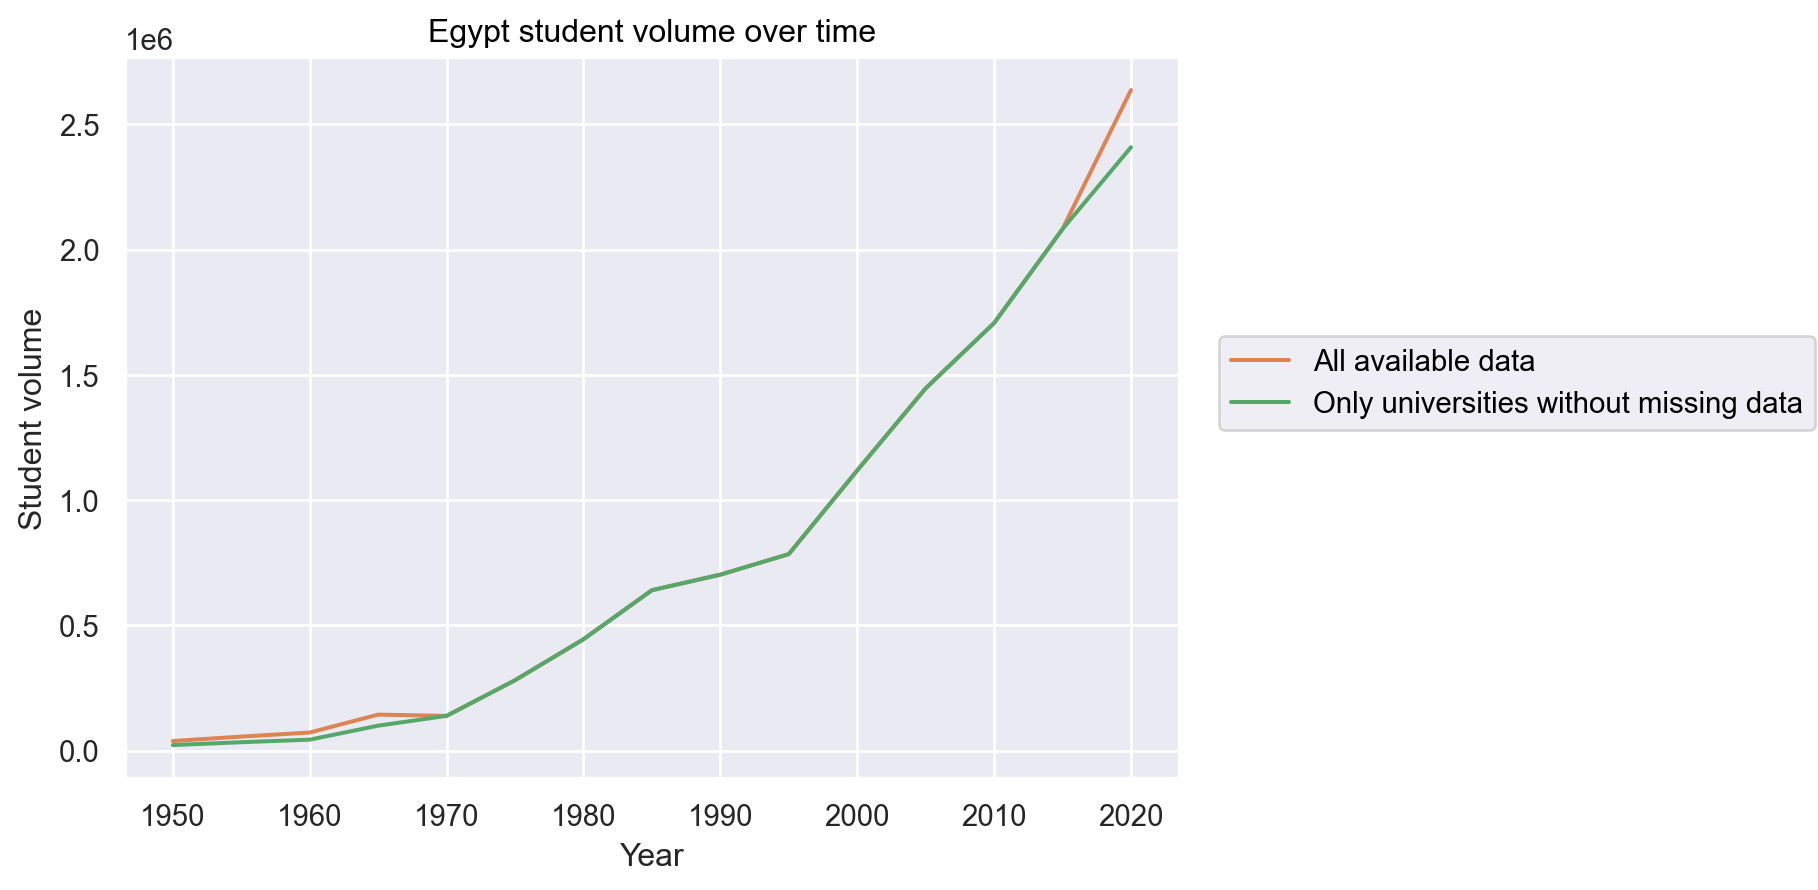

In [1046]:
make_country_ts('EGY', 'Egypt', id_with_miss_yrs)

In [1048]:
# Ukraine and Russia

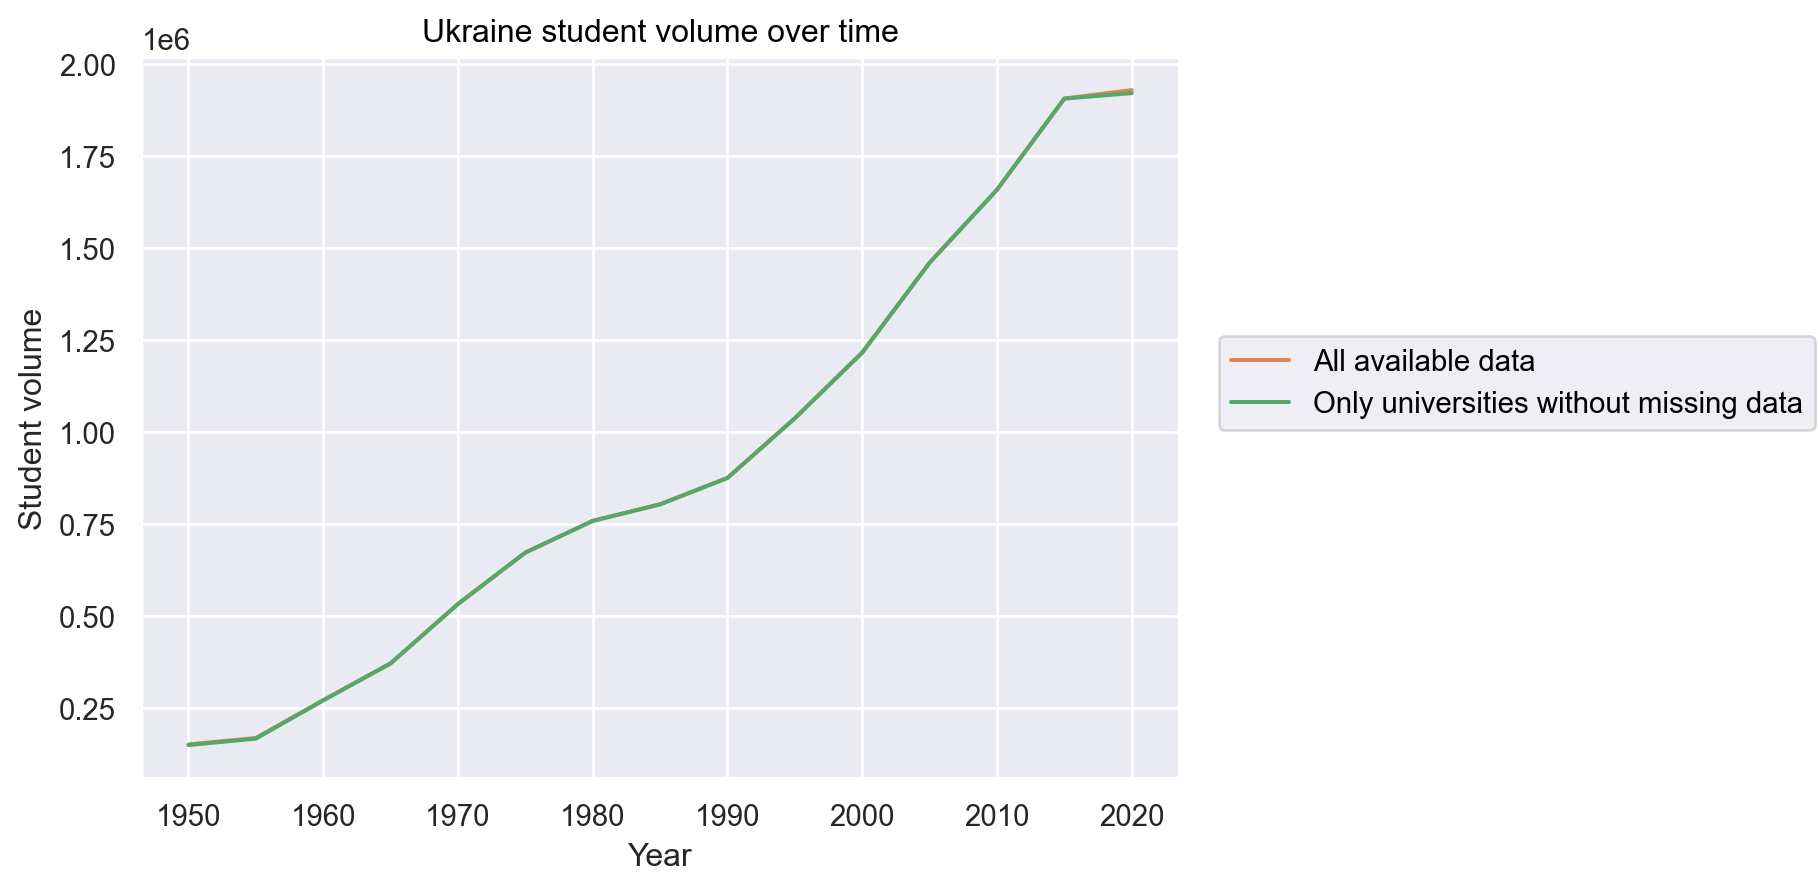

In [1050]:
make_country_ts('UKR', 'Ukraine', id_with_miss_yrs)

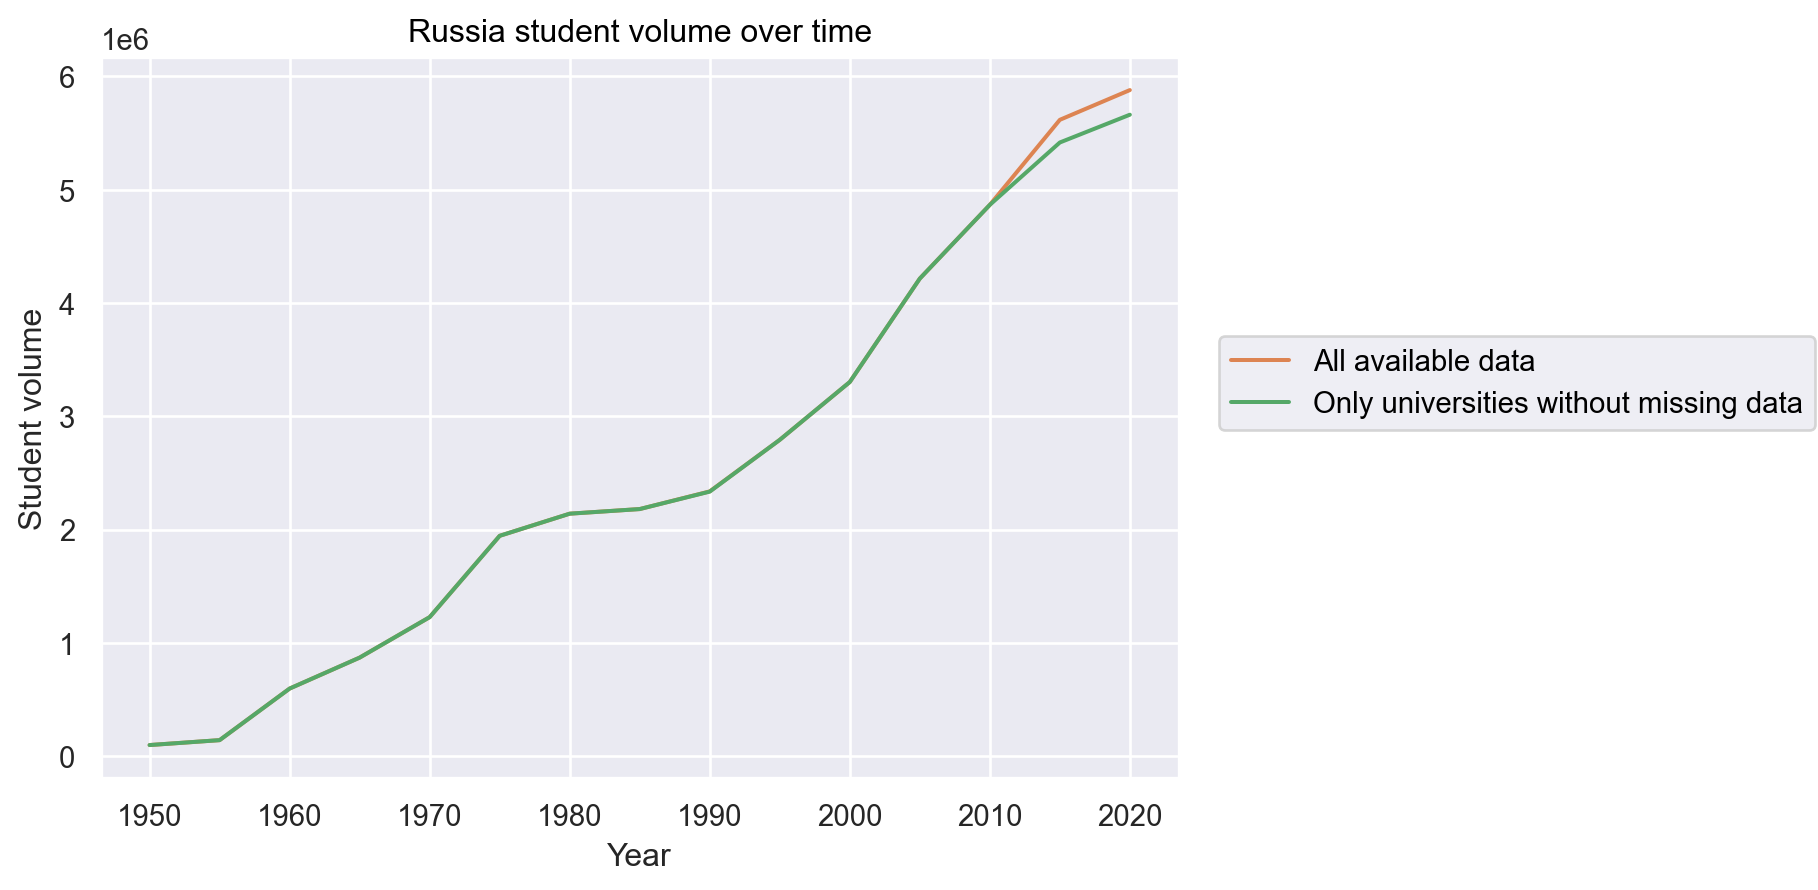

In [1052]:
make_country_ts('RUS', 'Russia', id_with_miss_yrs)

In [1054]:
# Birth control

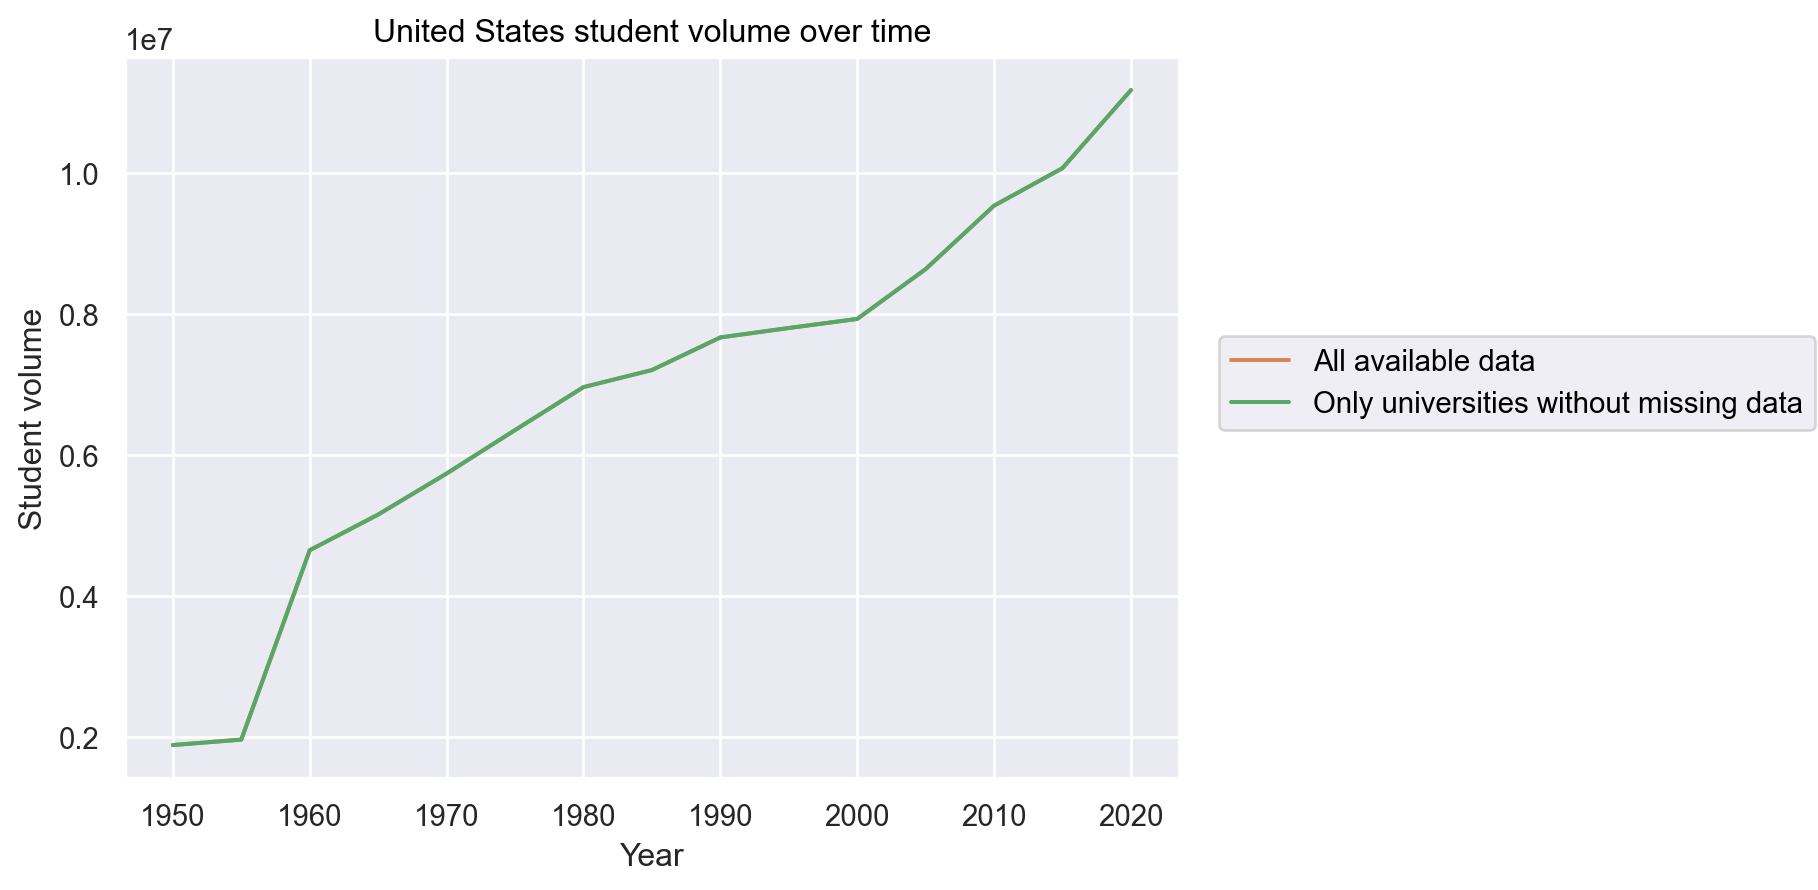

In [1056]:
make_country_ts('USA', 'United States', id_with_miss_yrs)

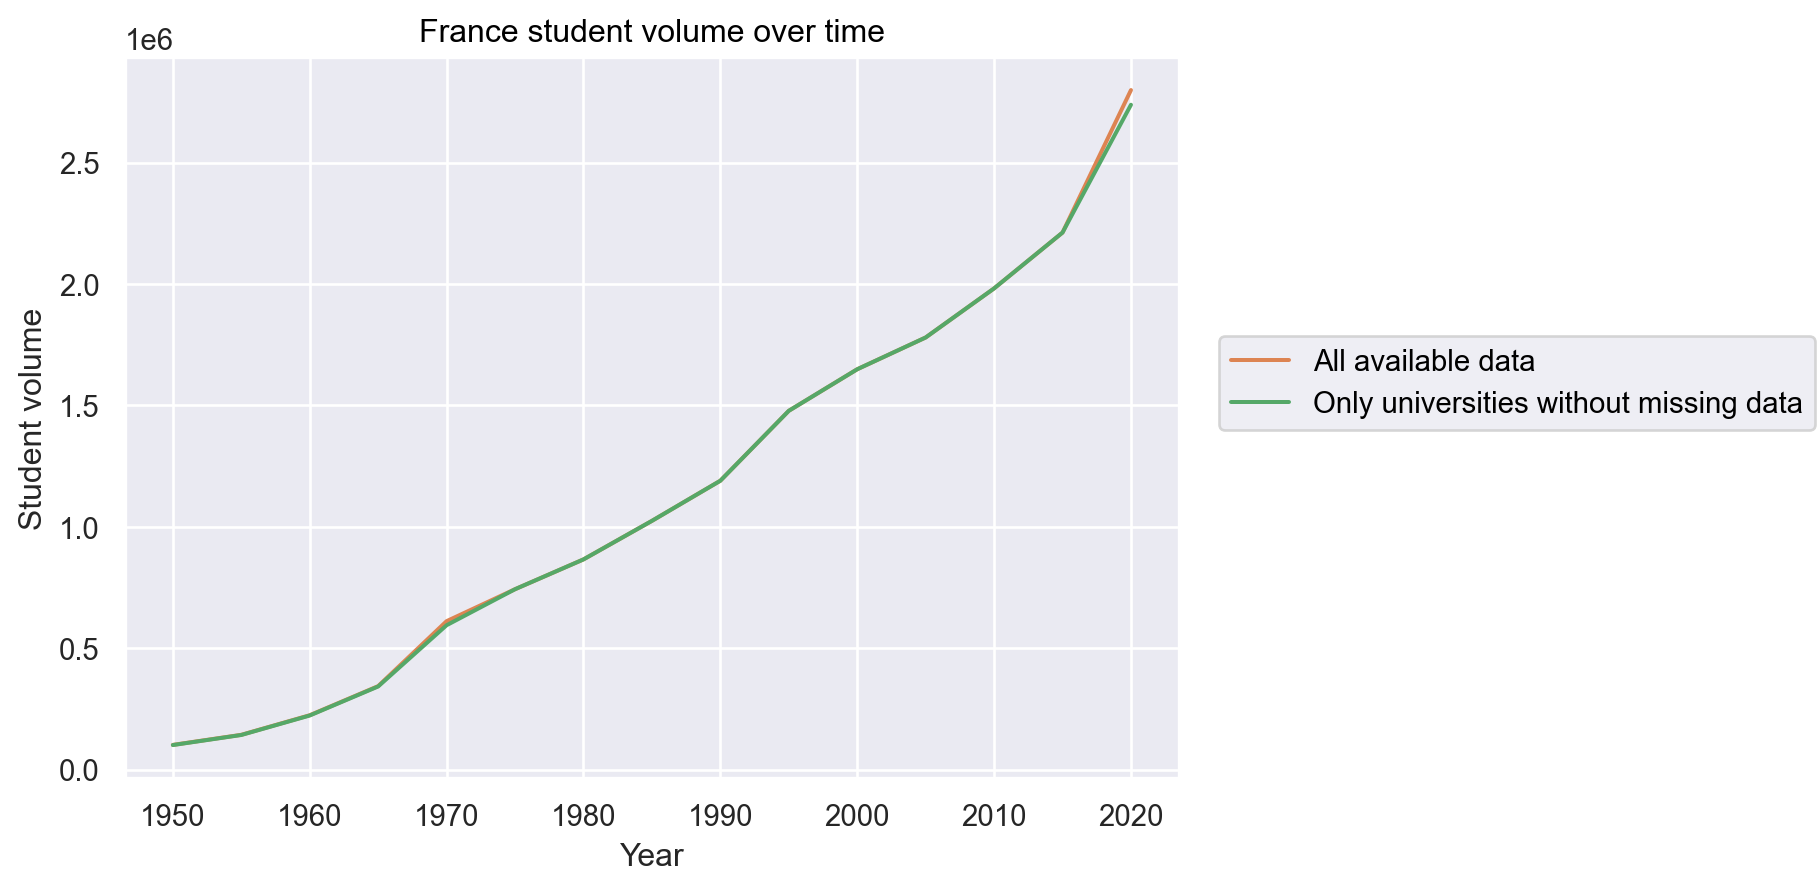

In [1058]:
make_country_ts('FRA', 'France', id_with_miss_yrs)

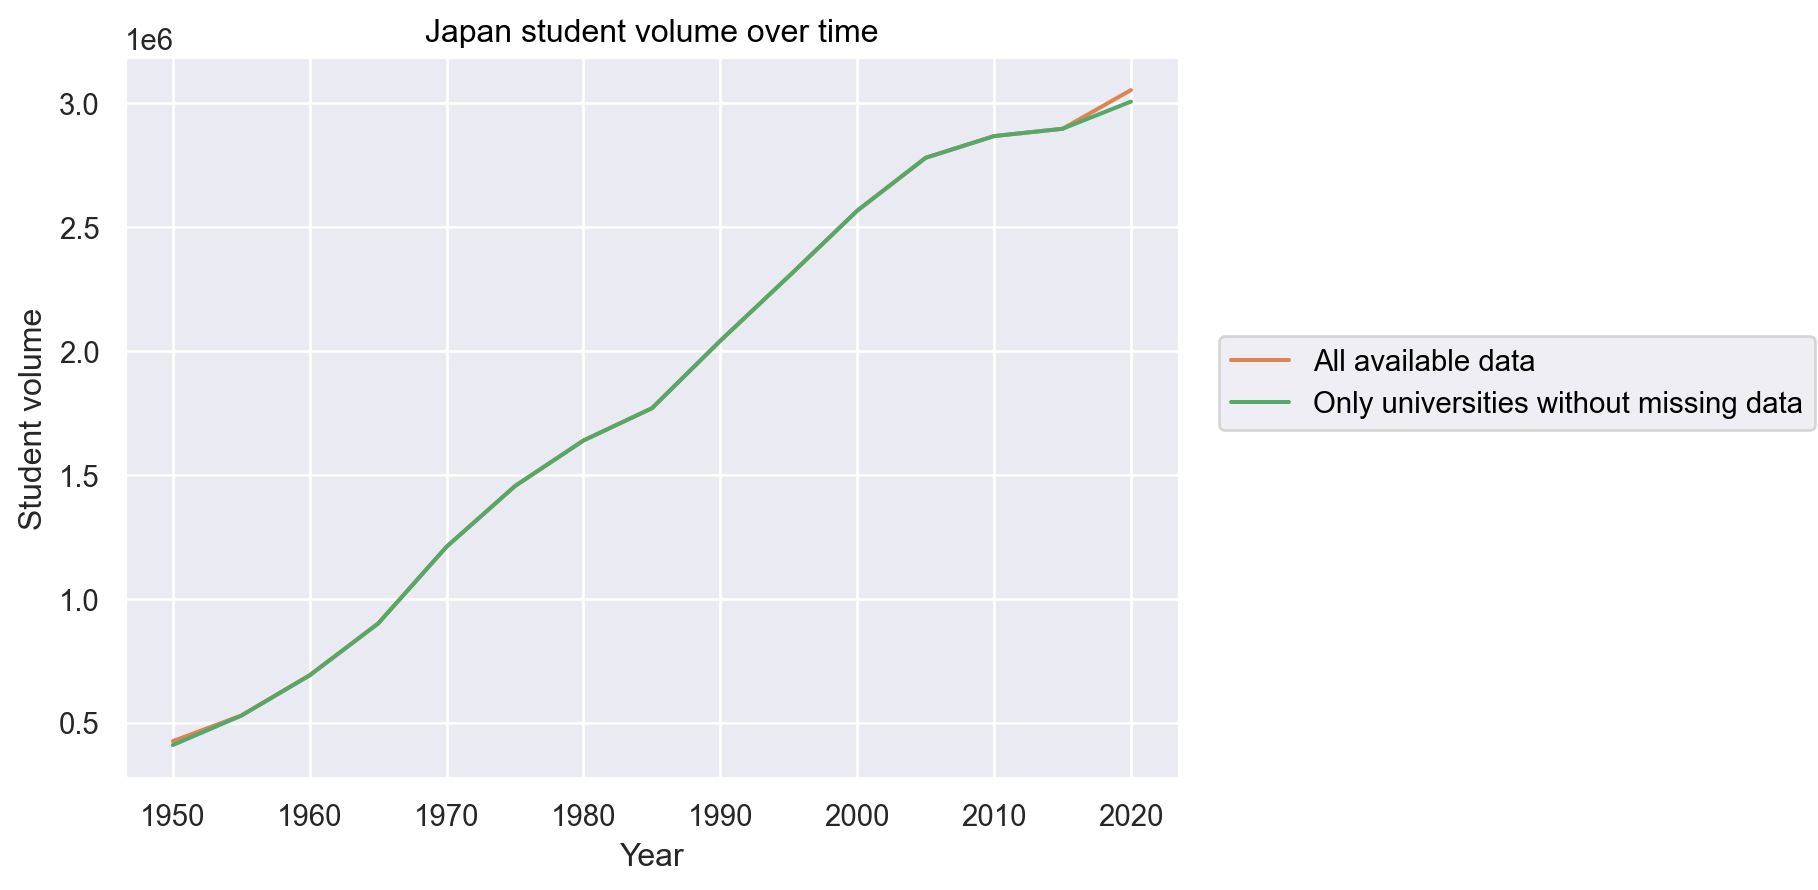

In [1060]:
make_country_ts('JPN', 'Japan', id_with_miss_yrs)

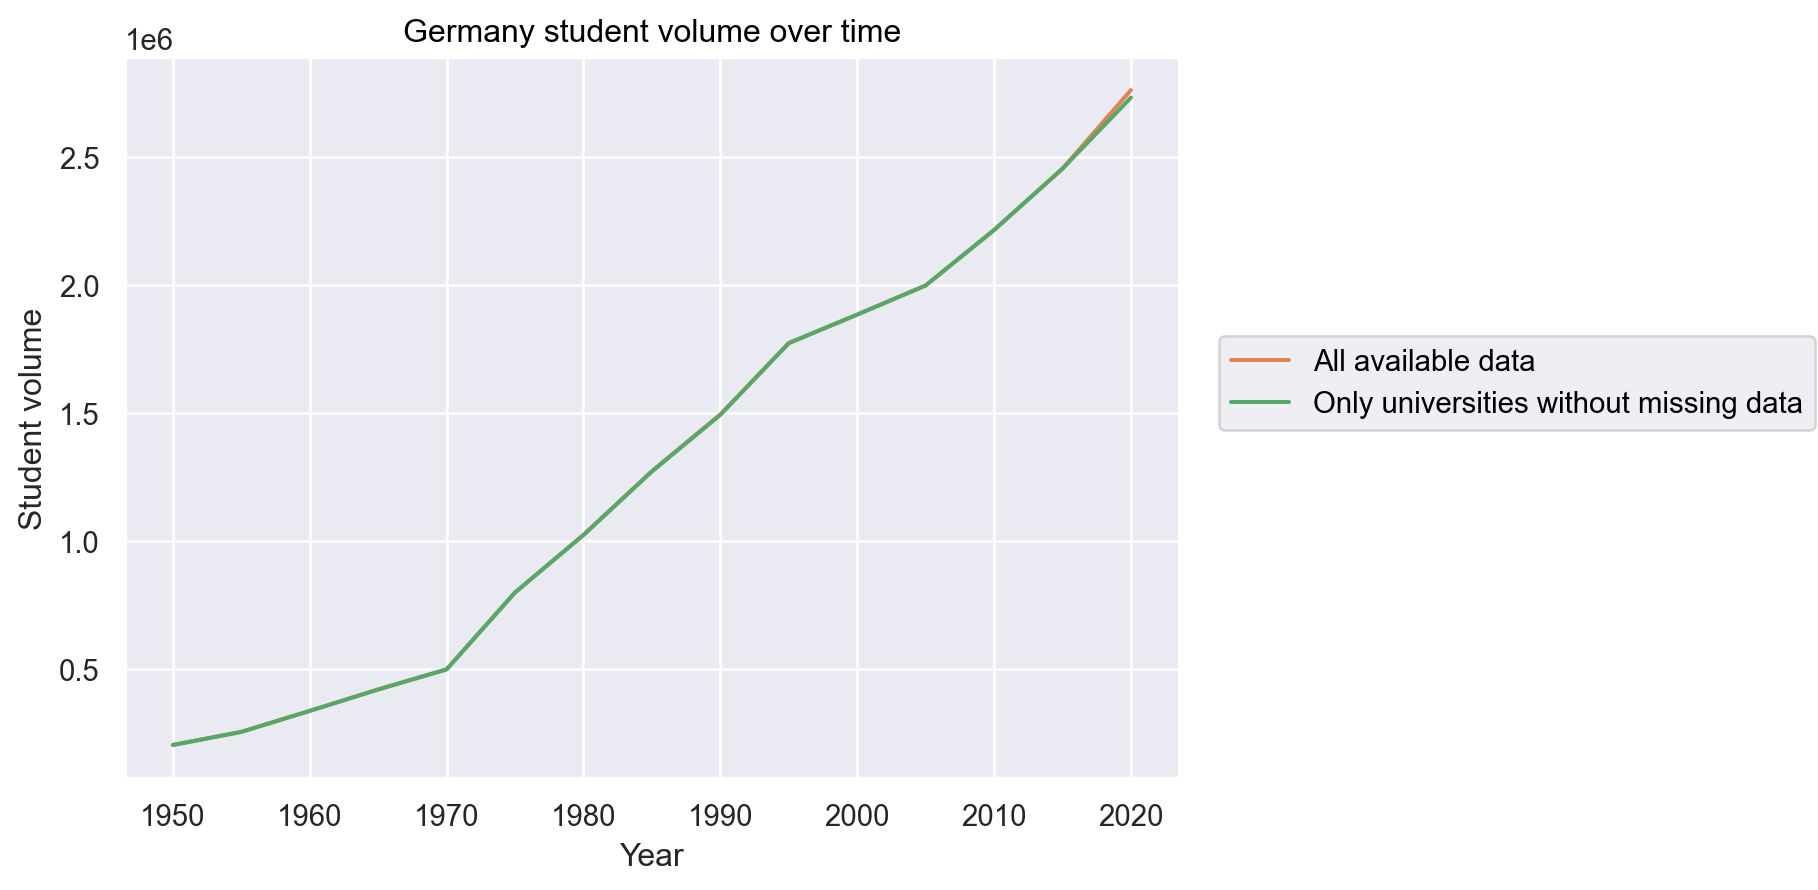

In [1062]:
make_country_ts('DEU', 'Germany', id_with_miss_yrs)

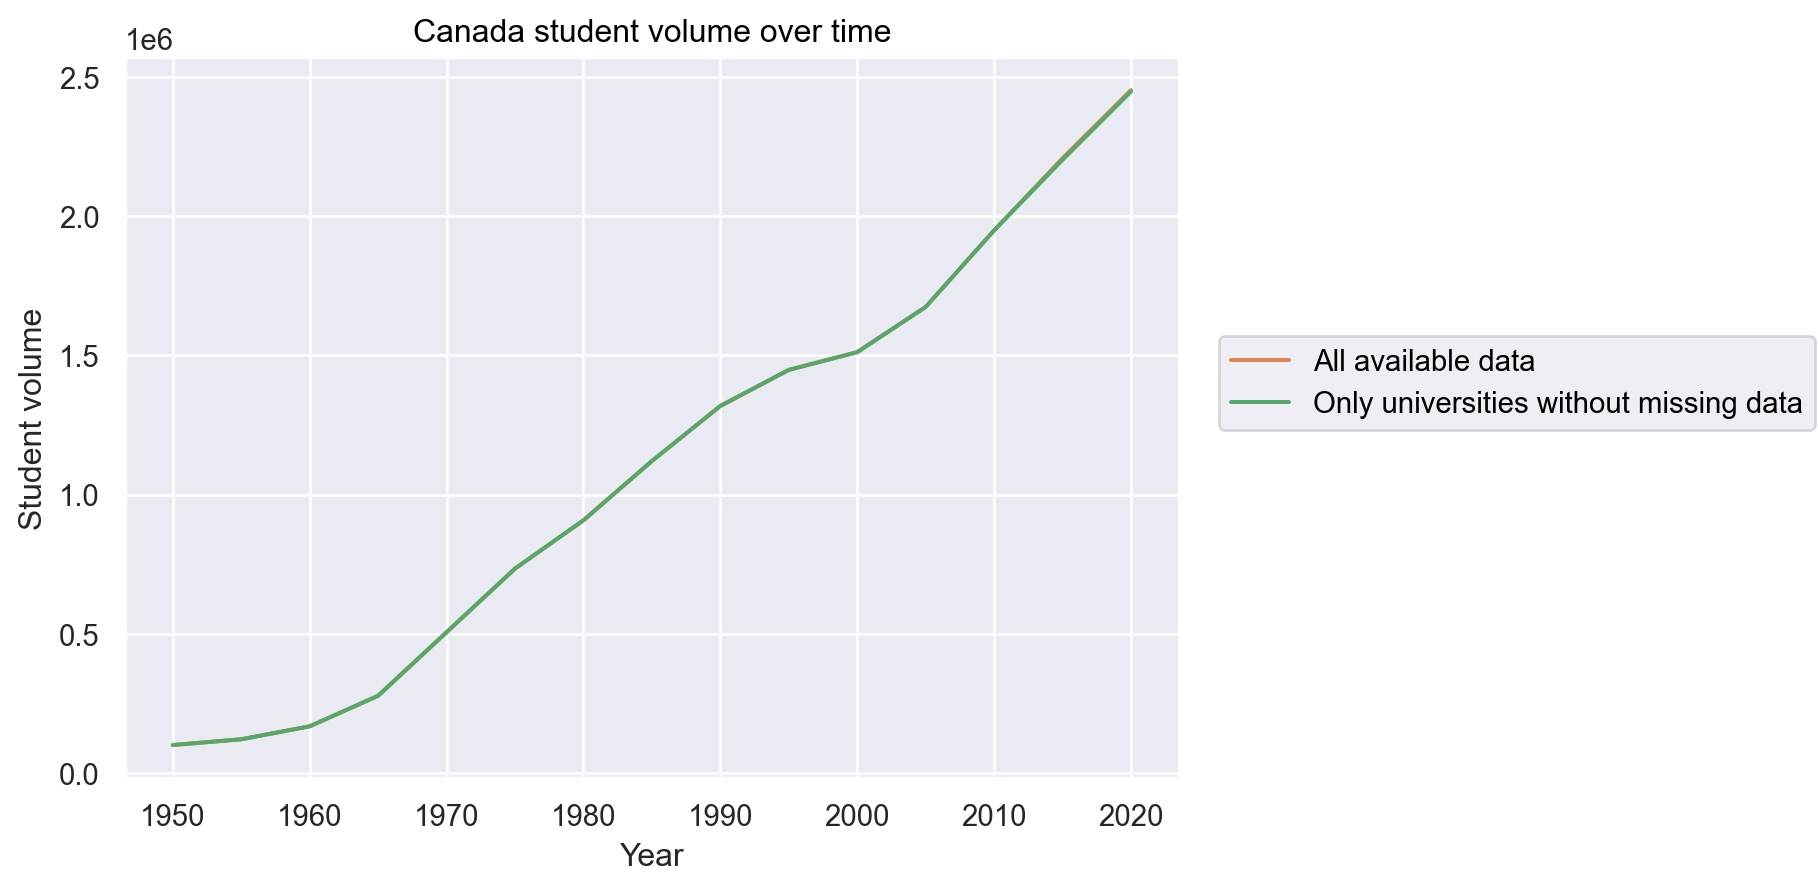

In [1064]:
make_country_ts('CAN', 'Canada', id_with_miss_yrs)

In [1066]:
# Fall of the berlin wall

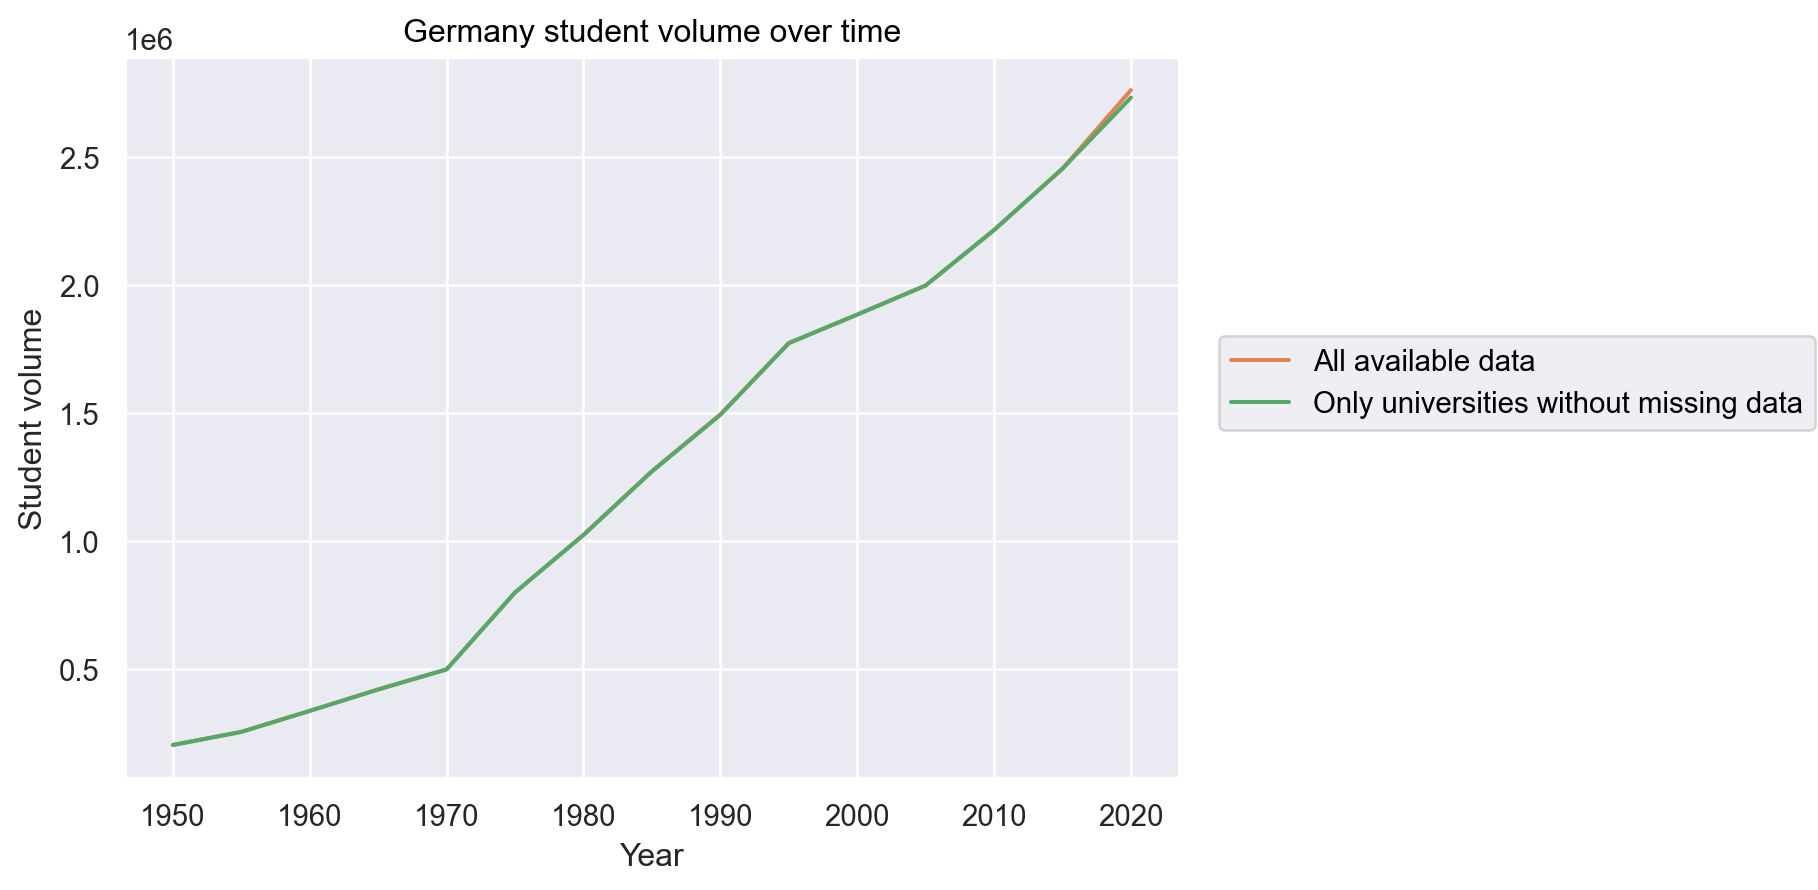

In [1068]:
make_country_ts('DEU', 'Germany', id_with_miss_yrs)

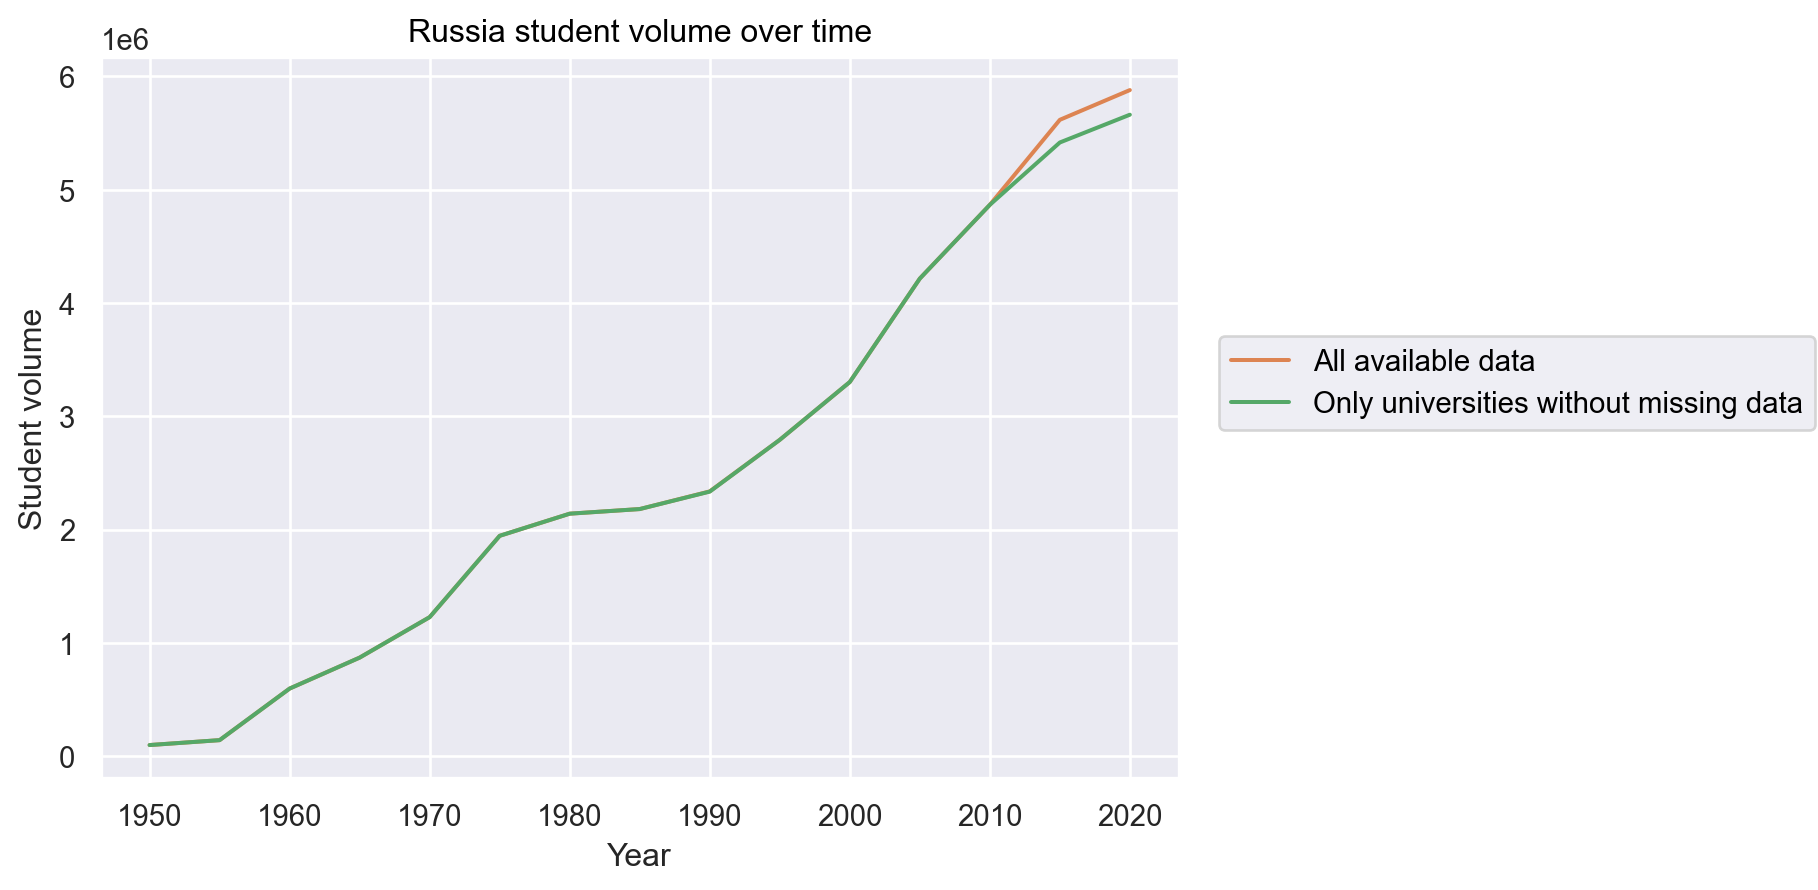

In [1070]:
make_country_ts('RUS', 'Russia', id_with_miss_yrs)

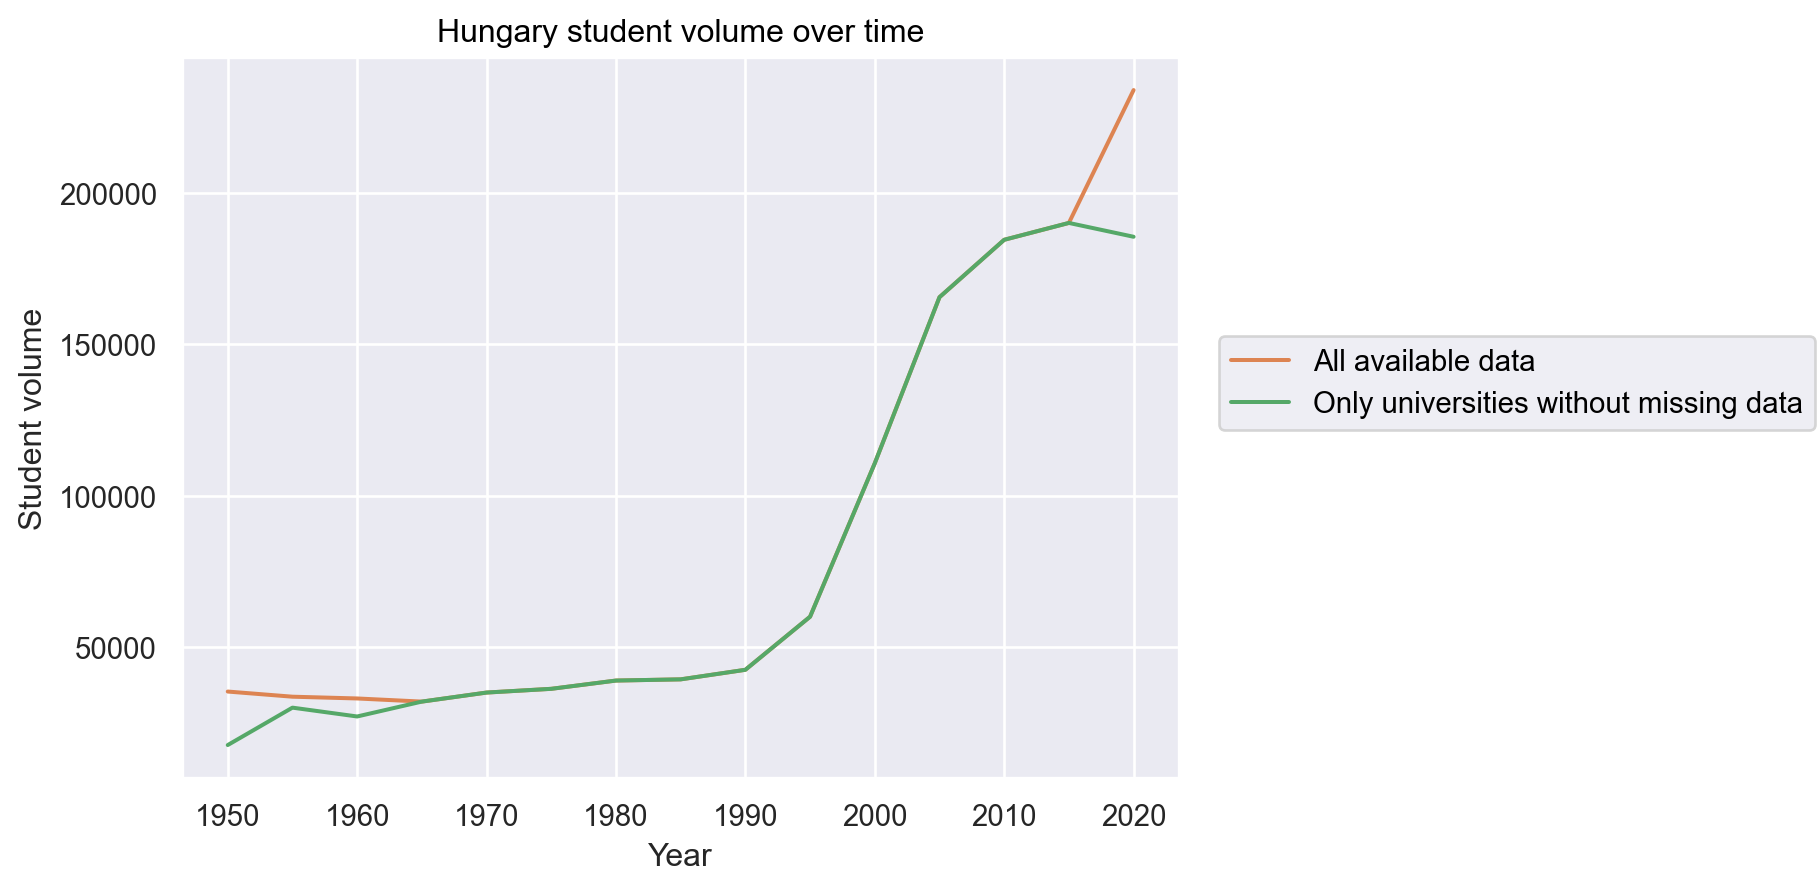

In [1072]:
make_country_ts('HUN', 'Hungary', id_with_miss_yrs)

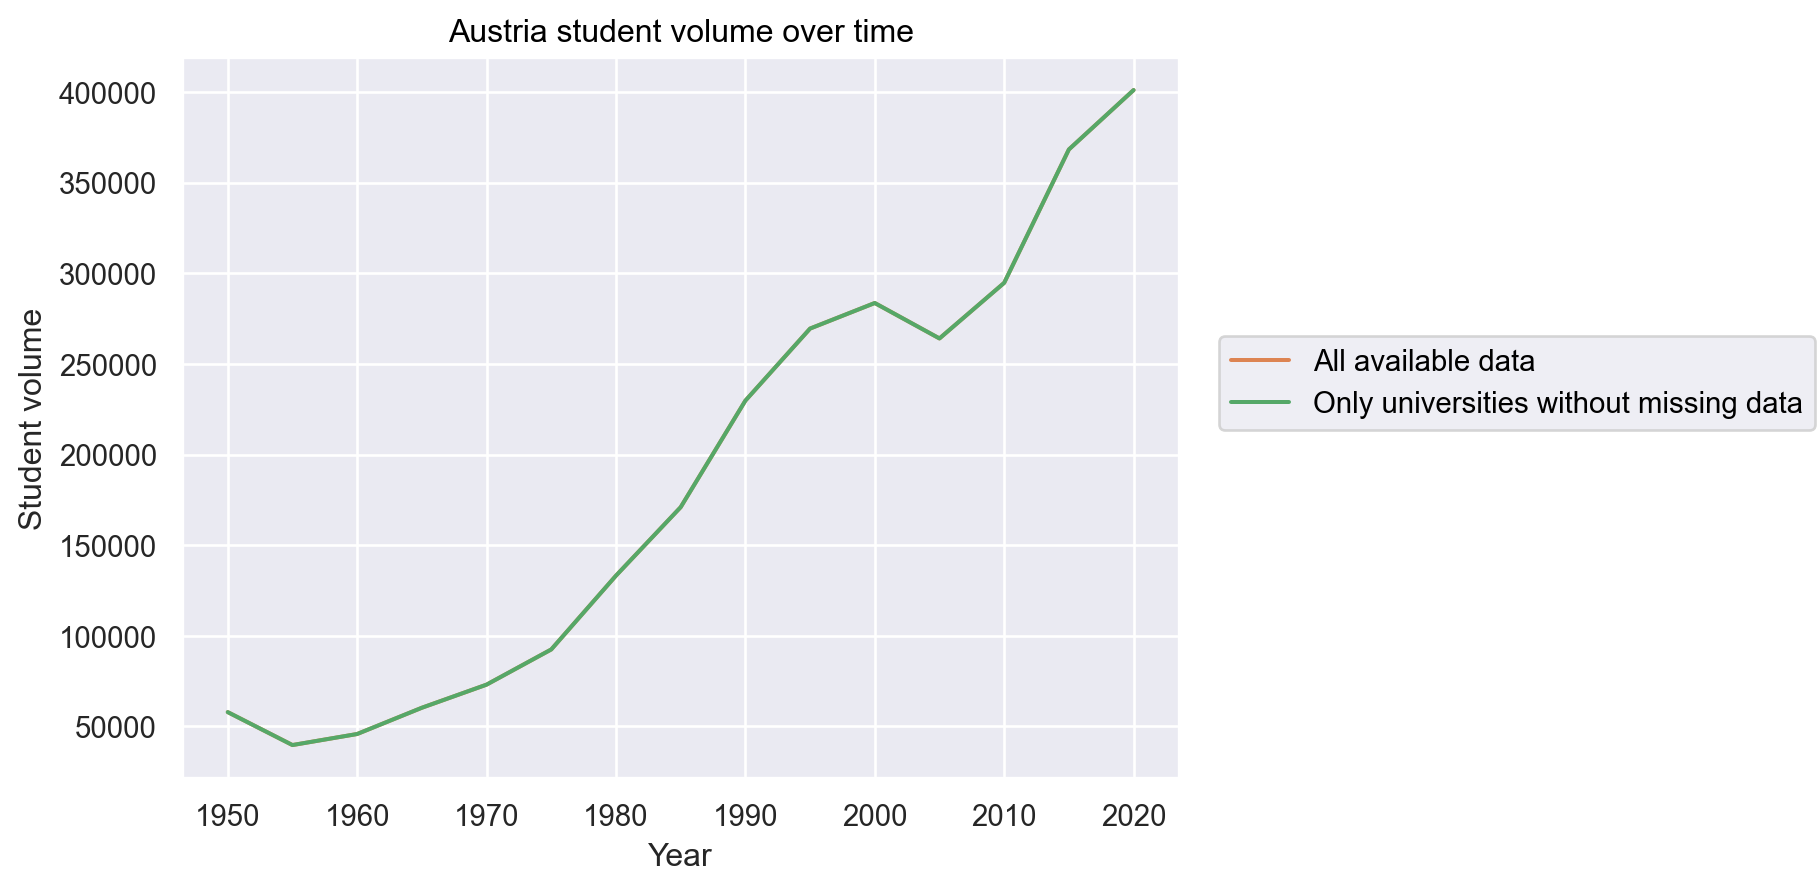

In [1074]:
make_country_ts('AUT', 'Austria', id_with_miss_yrs)

In [702]:
########## Question 3: GPD correlation ##########
# I looked at correlation of student growth (in 5yr increments) to GDP growth also in 5 year increments
# I also lagged GDP to see if current GDP affects current enrollment (people being able to afford university) vs.
# Educated individuals driving future GDP
# I excluded univerisities with incomplete data. 
# I also did some outlier removal I exclude GDP and student volume growth of more than 5x or falls 
# by more than 80% (with more time I would investigate more what is appropriate; look into what countries
# year get exclude)

# Findings

# GDP the year students are in university and 10 years prior matter for student volume growth. 
# Why a 10 year gap and not a 5 year gap I am not sure. I would want to plot these growth rates against 
# each other and look at whether certain years have a large effect

# GDP is most correlated to student volume growth in years prior. This suggests that growing higher ed, 
# grows GDP. With more time, I would validate this finding by looking at how it holds over year pairs.



In [1076]:
gdp = pd.read_csv("Countries GDP 1960-2020.csv")

In [1088]:
gdp_long = gdp.melt(id_vars=['Country Name', 'Country Code'])

In [1090]:
gdp_long['year'] = (np.ceil(gdp_long['variable'].astype(int)/5)*5).astype(int)
gdp5 = gdp_long.groupby(['Country Name', 'Country Code', 'year']).agg(
    {'value': 'mean'}).reset_index()

In [1093]:
def lag_gdp(gdp, lag):
    if lag / 5.0 != np.floor(lag/5.0):
        print ('You can only lag by 5 yr increments')
    else:
        gdp = gdp.sort_values(by=['Country Code', 'year']).reset_index(drop=True)
        gdp['prior'] = gdp.groupby('Country Code')['value'].shift(1)
        gdp['gdp_growth_lagged'] = (gdp['value'] / gdp['prior']).shift(int(lag / 5))
        return(gdp)

# lag_gdp(gdp5, 10)
# gdp5[['Country Name', 'Country Code', 'year', 'gdp_growth']]

In [1095]:
en_nona['exclude_ids_with_miss_yrs'] = np.where(
    en_nona.iau_id1.isin(id_with_miss_yrs), 0, en_nona.students5_estimated)
stu_yr_c = en_nona.groupby(['countrycode', 'year']).agg(
        {'students5_estimated':'sum', 'exclude_ids_with_miss_yrs': 'sum' }).reset_index()

stu_yr_c = stu_yr_c.sort_values(by=['countrycode', 'year']).reset_index(drop=True)
stu_yr_c['prior5yrs'] = stu_yr_c.groupby(
    'countrycode')['exclude_ids_with_miss_yrs'].shift(1)
stu_yr_c['stu_growth'] = stu_yr_c['exclude_ids_with_miss_yrs'] / stu_yr_c['prior5yrs']

In [1097]:
def get_corr(gdp, stu, lag, remove_outliers=5):
    gdp = lag_gdp(gdp, lag)
    df = pd.merge(
        gdp[['Country Name', 'Country Code', 'year', 'gdp_growth_lagged']], 
        stu[['countrycode', 'year', 'stu_growth']],
        left_on = ['Country Code', 'year'],
        right_on = ['countrycode', 'year']
    )
    df = df[(
        df.gdp_growth_lagged.isna() == False) & (df.stu_growth.isna() == False) & 
        (df.stu_growth < remove_outliers) & (df.gdp_growth_lagged < remove_outliers) & 
        (df.stu_growth > 1.0/remove_outliers) & (df.gdp_growth_lagged > 1.0/ remove_outliers)]
    return({
        'lag': 'GDP ' + str(lag) + " years ago",
        'n_obs': df.shape[0],
        'corr': stats.pearsonr(df['gdp_growth_lagged'], df['stu_growth'])})

In [1105]:
# for r in range(-30, 30, 5):
#     print(get_corr(gdp5, stu_yr_c, r, remove_outliers=1000)) # no outlier removal

In [1111]:
# for r in range(-30, 30, 5):
#     print(get_corr(gdp5, stu_yr_c, r, remove_outliers=2)) # no outlier removal

In [1103]:
for r in range(-30, 30, 5):
    print(get_corr(gdp5, stu_yr_c, r, remove_outliers=5)) # no outlier removal

{'lag': 'GDP -30 years ago', 'n_obs': 929, 'corr': PearsonRResult(statistic=-0.14447394727288673, pvalue=9.834631753577075e-06)}
{'lag': 'GDP -25 years ago', 'n_obs': 930, 'corr': PearsonRResult(statistic=-0.12701915564211813, pvalue=0.00010271125160363787)}
{'lag': 'GDP -20 years ago', 'n_obs': 929, 'corr': PearsonRResult(statistic=-0.05757664171173082, pvalue=0.07943054577174168)}
{'lag': 'GDP -15 years ago', 'n_obs': 929, 'corr': PearsonRResult(statistic=0.13580682658725515, pvalue=3.2813605107220514e-05)}
{'lag': 'GDP -10 years ago', 'n_obs': 928, 'corr': PearsonRResult(statistic=0.19336621037193732, pvalue=2.8723978153997698e-09)}
{'lag': 'GDP -5 years ago', 'n_obs': 929, 'corr': PearsonRResult(statistic=0.12841747163061268, pvalue=8.66962750868831e-05)}
{'lag': 'GDP 0 years ago', 'n_obs': 960, 'corr': PearsonRResult(statistic=0.09074842830759615, pvalue=0.004894724418883468)}
{'lag': 'GDP 5 years ago', 'n_obs': 948, 'corr': PearsonRResult(statistic=0.0019317005067654137, pvalue=0